In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,return_frequency,avg_delivery_days,delivery_fee_sensitivity,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level
count,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,...,11789.00000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000
mean,48.729409,131704.282382,6.011367,7.597930,2.514471,5.498770,5.534312,24.677581,9.482144,74554.929341,...,4.46747,3.999661,5.468827,5.462041,5.518704,5.486386,5.485368,5.532021,5.448554,5.504114
std,17.899445,68120.726684,1.976811,4.011628,1.263047,2.880366,2.887251,14.431277,5.728825,43167.126595,...,2.88545,1.995881,2.870195,2.882177,2.867613,2.877918,2.877264,2.848796,2.872740,2.876561
min,18.000000,15005.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,523.000000,...,0.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,33.000000,72450.000000,4.600000,4.000000,1.600000,3.000000,3.000000,12.000000,5.000000,36797.000000,...,2.00000,2.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
50%,49.000000,131916.000000,6.000000,8.000000,2.500000,5.000000,6.000000,25.000000,9.000000,74859.000000,...,4.00000,4.000000,5.000000,5.000000,6.000000,5.000000,5.000000,6.000000,5.000000,6.000000
75%,64.000000,190505.000000,7.400000,11.000000,3.400000,8.000000,8.000000,37.000000,14.000000,112134.000000,...,7.00000,6.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000
max,79.000000,249989.000000,12.000000,14.000000,6.000000,10.000000,10.000000,49.000000,19.000000,149996.000000,...,9.00000,7.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


In [4]:
df = pd.read_csv('Consumer_Shopping_Trends_2026.csv')
print('Dimensiones:', df.shape)
df.head()

In [5]:
df.info()

Dimensiones: (11789, 25)


,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level,gender,city_tier,shopping_preference
0,56,221111,6.5,12,0.7,1,6,16,16,28551,...,7,7,1,3,6,5,2,Other,Tier 3,Store
1,69,96029,8.2,13,2.7,6,9,14,1,124056,...,3,4,9,6,8,1,7,Male,Tier 3,Hybrid
2,46,19055,6.4,4,2.1,10,8,2,0,81939,...,4,10,1,1,3,3,3,Female,Tier 3,Store
3,32,53170,6.4,11,0.7,2,10,20,3,35901,...,10,2,4,8,2,6,6,Female,Tier 1,Store
4,60,244016,6.0,5,0.7,2,5,18,16,131971,...,2,5,8,9,7,1,6,Male,Tier 3,Store


In [6]:
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11789 entries, 0 to 11788
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          11789 non-null  int64  
 1   monthly_income               11789 non-null  int64  
 2   daily_internet_hours         11789 non-null  float64
 3   smartphone_usage_years       11789 non-null  int64  
 4   social_media_hours           11789 non-null  float64
 5   online_payment_trust_score   11789 non-null  int64  
 6   tech_savvy_score             11789 non-null  int64  
 7   monthly_online_orders        11789 non-null  int64  
 8   monthly_store_visits         11789 non-null  int64  
 9   avg_online_spend             11789 non-null  int64  
 10  avg_store_spend              11789 non-null  int64  
 11  discount_sensitivity         11789 non-null  int64  
 12  return_frequency             11789 non-null  int64  
 13  avg_delivery_day

In [7]:
print('Valores nulos por columna:')
print(df.isnull().sum())
print('\nTotal de filas duplicadas:', df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11789 entries, 0 to 11788
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          11789 non-null  int64  
 1   monthly_income               11789 non-null  int64  
 2   daily_internet_hours         11789 non-null  float64
 3   smartphone_usage_years       11789 non-null  int64  
 4   social_media_hours           11789 non-null  float64
 5   online_payment_trust_score   11789 non-null  int64  
 6   tech_savvy_score             11789 non-null  int64  
 7   monthly_online_orders        11789 non-null  int64  
 8   monthly_store_visits         11789 non-null  int64  
 9   avg_online_spend             11789 non-null  int64  
 10  avg_store_spend              11789 non-null  int64  
 11  discount_sensitivity         11789 non-null  int64  
 12  return_frequency             11789 non-null  int64  
 13  avg_delivery_day

In [8]:
print('Distribucion de la variable objetivo:')
print(df['shopping_preference'].value_counts())
print()
print(df['shopping_preference'].value_counts(normalize=True).round(4) * 100)

Dimensiones: (11789, 25)


,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level,gender,city_tier,shopping_preference
0,56,221111,6.5,12,0.7,1,6,16,16,28551,...,7,7,1,3,6,5,2,Other,Tier 3,Store
1,69,96029,8.2,13,2.7,6,9,14,1,124056,...,3,4,9,6,8,1,7,Male,Tier 3,Hybrid
2,46,19055,6.4,4,2.1,10,8,2,0,81939,...,4,10,1,1,3,3,3,Female,Tier 3,Store
3,32,53170,6.4,11,0.7,2,10,20,3,35901,...,10,2,4,8,2,6,6,Female,Tier 1,Store
4,60,244016,6.0,5,0.7,2,5,18,16,131971,...,2,5,8,9,7,1,6,Male,Tier 3,Store


In [9]:
df['shopping_preference'].value_counts().plot(kind='bar', color=['#2ecc71','#3498db','#e74c3c'])
plt.title('Distribucion de Preferencia de Compra')
plt.xlabel('Preferencia')
plt.ylabel('Cantidad')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [10]:
print('Valores unicos en columnas categoricas:')
print('gender:', df['gender'].unique())
print('city_tier:', df['city_tier'].unique())

Valores nulos por columna:
age                            0
monthly_income                 0
daily_internet_hours           0
smartphone_usage_years         0
social_media_hours             0
online_payment_trust_score     0
tech_savvy_score               0
monthly_online_orders          0
monthly_store_visits           0
avg_online_spend               0
avg_store_spend                0
discount_sensitivity           0
return_frequency               0
avg_delivery_days              0
delivery_fee_sensitivity       0
free_return_importance         0
product_availability_online    0
impulse_buying_score           0
need_touch_feel_score          0
brand_loyalty_score            0
environmental_awareness        0
time_pressure_level            0
gender                         0
city_tier                      0
shopping_preference            0
dtype: int64

Total de filas duplicadas: 0


In [11]:
le_gender = LabelEncoder()
le_city = LabelEncoder()
le_target = LabelEncoder()

df['gender_encoded'] = le_gender.fit_transform(df['gender'])
df['city_tier_encoded'] = le_city.fit_transform(df['city_tier'])
df['target'] = le_target.fit_transform(df['shopping_preference'])

print('Mapeo gender:', dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_))))
print('Mapeo city_tier:', dict(zip(le_city.classes_, le_city.transform(le_city.classes_))))
print('Mapeo target:', dict(zip(le_target.classes_, le_target.transform(le_target.classes_))))

Mapeo gender: {'Female': 0, 'Male': 1, 'Other': 2}
Mapeo city_tier: {'Tier 1': 0, 'Tier 2': 1, 'Tier 3': 2}
Mapeo target: {'Hybrid': 0, 'Online': 1, 'Store': 2}


In [12]:
features = ['age', 'monthly_income', 'daily_internet_hours', 'smartphone_usage_years',
            'social_media_hours', 'online_payment_trust_score', 'tech_savvy_score',
            'monthly_online_orders', 'monthly_store_visits', 'avg_online_spend',
            'avg_store_spend', 'discount_sensitivity', 'return_frequency',
            'avg_delivery_days', 'delivery_fee_sensitivity', 'free_return_importance',
            'product_availability_online', 'impulse_buying_score', 'need_touch_feel_score',
            'brand_loyalty_score', 'environmental_awareness', 'time_pressure_level',
            'gender_encoded', 'city_tier_encoded']

X = df[features]
y = df['target']

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (11789, 24)
y shape: (11789,)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print('Entrenamiento:', X_train.shape)
print('Prueba:', X_test.shape)

Entrenamiento: (8252, 24)
Prueba: (3537, 24)


In [14]:
print('=== MODELO 1: Arbol SIN poda (Memorion) ===')
arbol_memorion = DecisionTreeClassifier(random_state=42)
arbol_memorion.fit(X_train, y_train)

y_pred_train_mem = arbol_memorion.predict(X_train)
y_pred_test_mem = arbol_memorion.predict(X_test)

print(f'Exactitud en ENTRENAMIENTO: {accuracy_score(y_train, y_pred_train_mem):.4f}')
print(f'Exactitud en PRUEBA: {accuracy_score(y_test, y_pred_test_mem):.4f}')
print(f'Profundidad del arbol: {arbol_memorion.get_depth()}')
print(f'Numero de hojas: {arbol_memorion.get_n_leaves()}')

=== MODELO 1: Arbol SIN poda (Memorion) ===
Exactitud en ENTRENAMIENTO: 1.0000
Exactitud en PRUEBA: 0.9276
Profundidad del arbol: 13
Numero de hojas: 320


In [15]:
print('=== Reporte de Clasificacion - Memorion (Test) ===')
print(classification_report(y_test, y_pred_test_mem, target_names=le_target.classes_))

=== Reporte de Clasificacion - Memorion (Test) ===
              precision    recall  f1-score   support

      Hybrid       0.21      0.26      0.23       111
      Online       0.80      0.78      0.79       353
       Store       0.98      0.97      0.97      3073

    accuracy                           0.93      3537
   macro avg       0.66      0.67      0.66      3537
weighted avg       0.93      0.93      0.93      3537



In [16]:
print('Matriz de Confusion - Memorion:')
print(confusion_matrix(y_test, y_pred_test_mem))

Matriz de Confusion - Memorion:
[[  29   31   51]
 [  54  274   25]
 [  58   37 2978]]


In [17]:
print('=== MODELO 2: Arbol con PODA (max_depth=5) ===')
arbol_podado = DecisionTreeClassifier(max_depth=5, min_samples_split=50, min_samples_leaf=20, random_state=42)
arbol_podado.fit(X_train, y_train)

y_pred_train_pod = arbol_podado.predict(X_train)
y_pred_test_pod = arbol_podado.predict(X_test)

print(f'Exactitud en ENTRENAMIENTO: {accuracy_score(y_train, y_pred_train_pod):.4f}')
print(f'Exactitud en PRUEBA: {accuracy_score(y_test, y_pred_test_pod):.4f}')
print(f'Profundidad del arbol: {arbol_podado.get_depth()}')
print(f'Numero de hojas: {arbol_podado.get_n_leaves()}')

=== MODELO 2: Arbol con PODA (max_depth=5) ===
Exactitud en ENTRENAMIENTO: 0.9456
Exactitud en PRUEBA: 0.9386
Profundidad del arbol: 5
Numero de hojas: 31


In [18]:
print('=== Reporte de Clasificacion - Podado (Test) ===')
print(classification_report(y_test, y_pred_test_pod, target_names=le_target.classes_))

=== Reporte de Clasificacion - Podado (Test) ===
              precision    recall  f1-score   support

      Hybrid       0.00      0.00      0.00       111
      Online       0.73      0.86      0.79       353
       Store       0.97      0.98      0.97      3073

    accuracy                           0.94      3537
   macro avg       0.57      0.61      0.59      3537
weighted avg       0.91      0.94      0.92      3537



c:\Users\ttvga\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ttvga\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ttvga\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [19]:
print('Matriz de Confusion - Podado:')
print(confusion_matrix(y_test, y_pred_test_pod))

Matriz de Confusion - Podado:
[[   0   54   57]
 [   0  304   49]
 [   0   57 3016]]


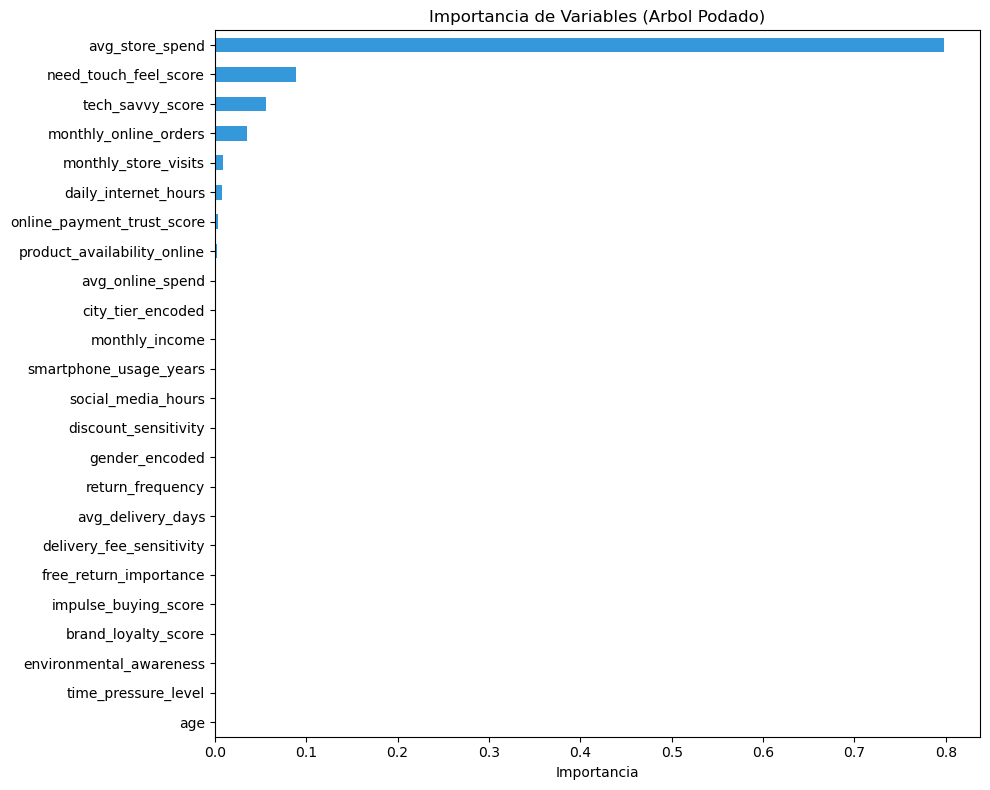

In [20]:
importancias = pd.Series(arbol_podado.feature_importances_, index=features).sort_values(ascending=True)
importancias.plot(kind='barh', figsize=(10, 8), color='#3498db')
plt.title('Importancia de Variables (Arbol Podado)')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

In [21]:
print('Top 5 variables mas importantes:')
print(importancias.sort_values(ascending=False).head())

Top 5 variables mas importantes:
avg_store_spend          0.797528
need_touch_feel_score    0.088673
tech_savvy_score         0.056402
monthly_online_orders    0.035661
monthly_store_visits     0.008796
dtype: float64


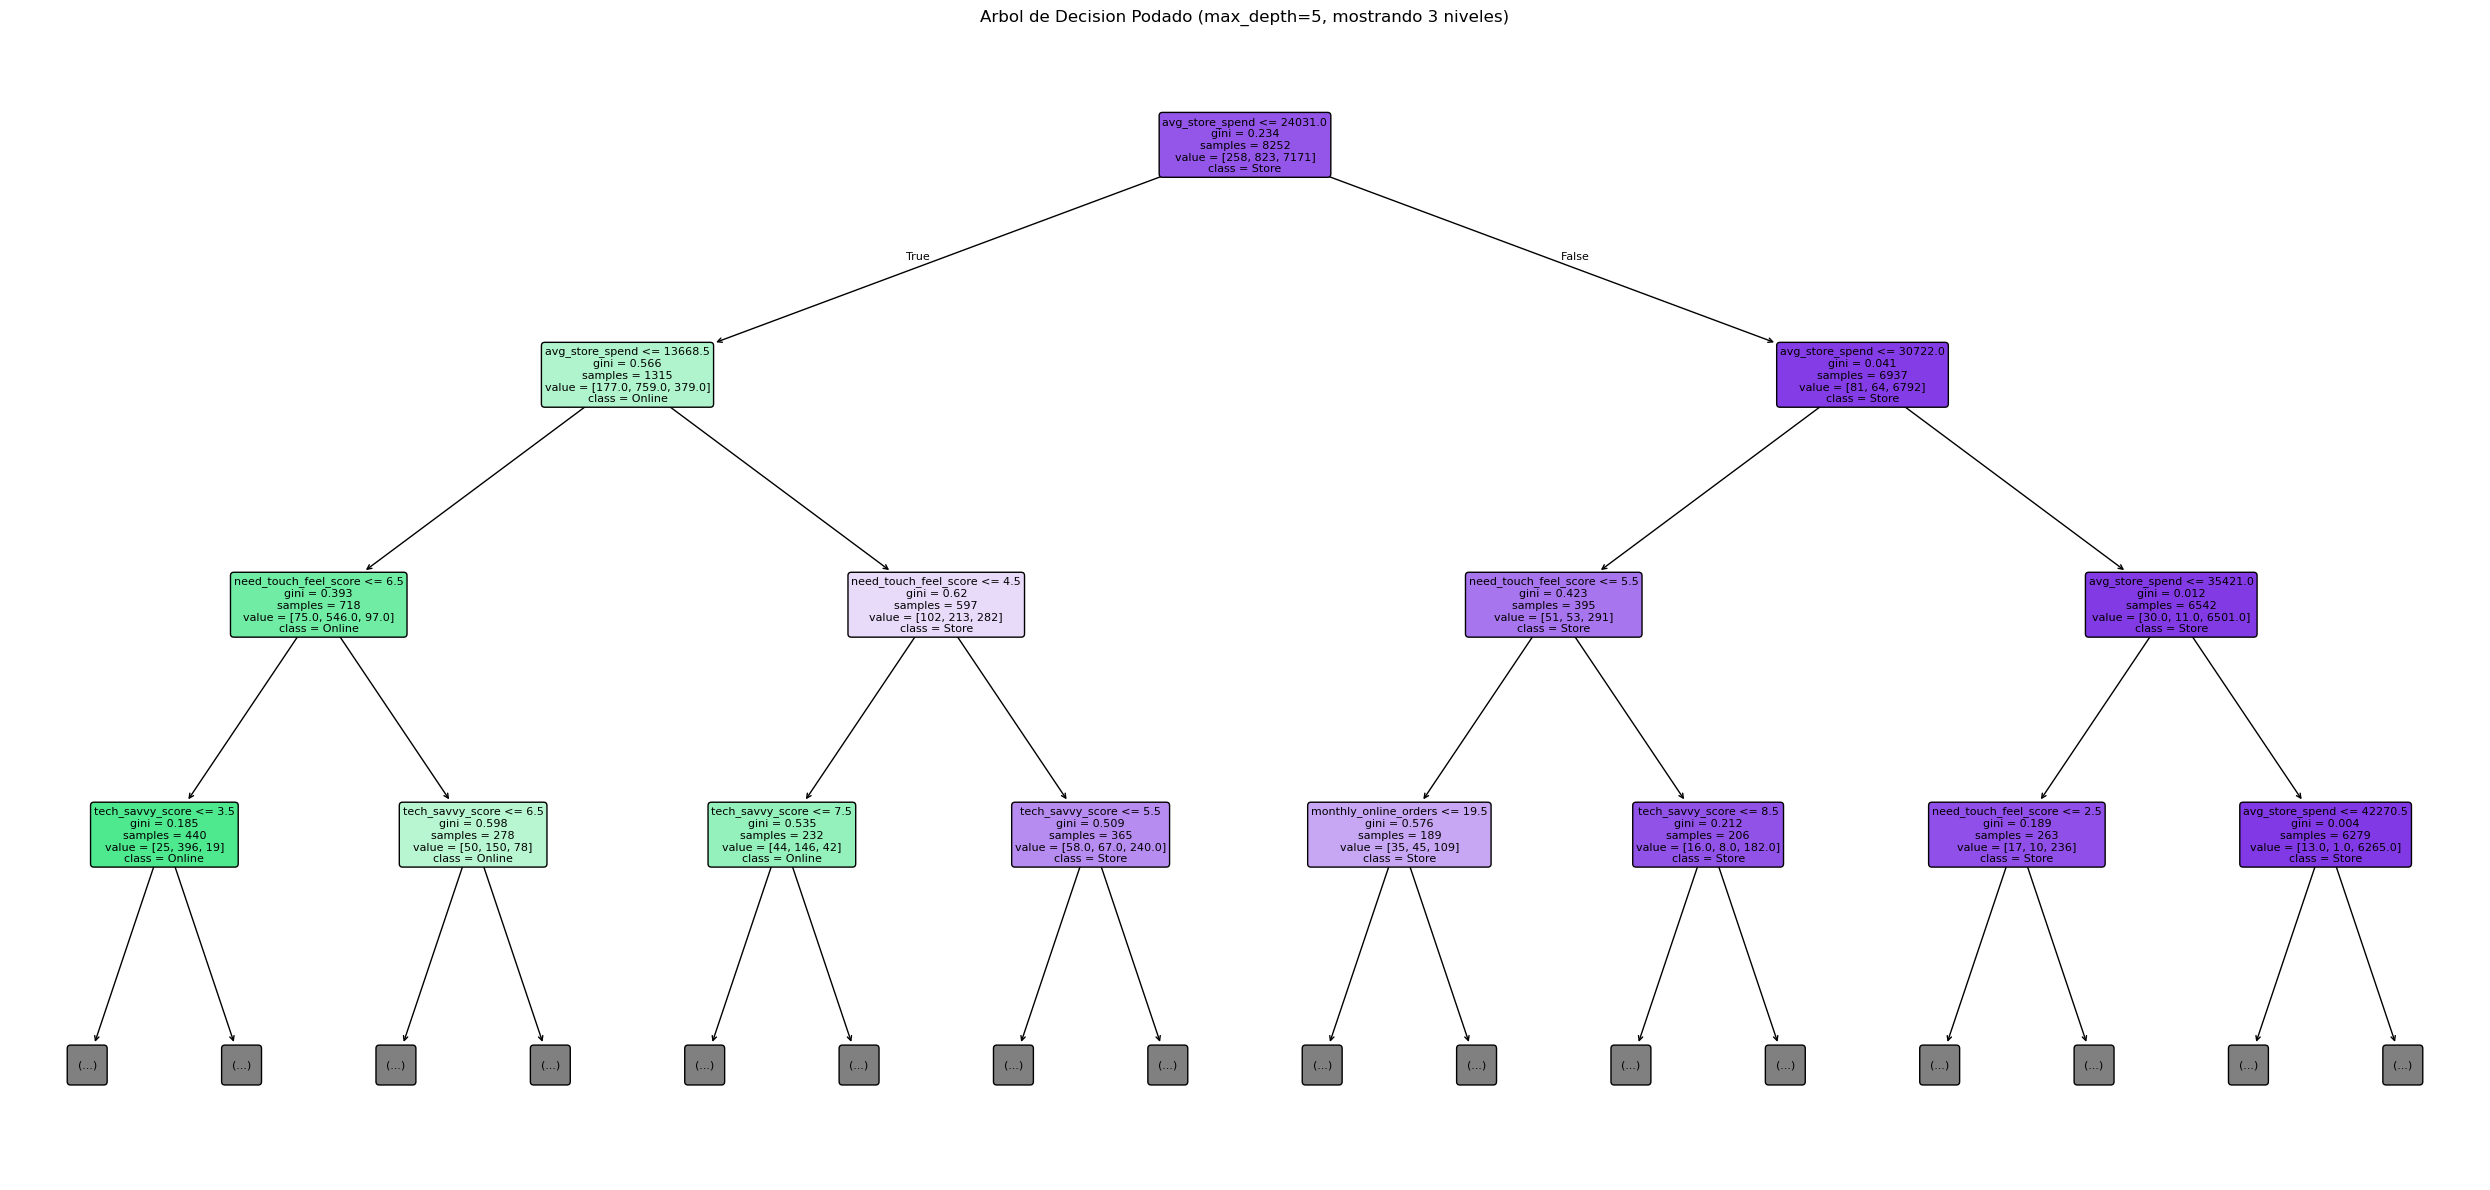

In [22]:
plt.figure(figsize=(25, 12))
plot_tree(arbol_podado, feature_names=features, class_names=le_target.classes_,
          filled=True, rounded=True, fontsize=8, max_depth=3)
plt.title('Arbol de Decision Podado (max_depth=5, mostrando 3 niveles)')
plt.tight_layout()
plt.show()

In [23]:
print('=== Comparacion de Modelos ===')
print(f'{"Modelo":<25} {"Acc Train":<15} {"Acc Test":<15} {"Profundidad":<15} {"Hojas"}')
print('-' * 75)
print(f'{"Memorion (sin poda)":<25} {accuracy_score(y_train, y_pred_train_mem):<15.4f} {accuracy_score(y_test, y_pred_test_mem):<15.4f} {arbol_memorion.get_depth():<15} {arbol_memorion.get_n_leaves()}')
print(f'{"Podado (depth=5)":<25} {accuracy_score(y_train, y_pred_train_pod):<15.4f} {accuracy_score(y_test, y_pred_test_pod):<15.4f} {arbol_podado.get_depth():<15} {arbol_podado.get_n_leaves()}')

=== Comparacion de Modelos ===
Modelo                    Acc Train       Acc Test        Profundidad     Hojas
---------------------------------------------------------------------------
Memorion (sin poda)       1.0000          0.9276          13              320
Podado (depth=5)          0.9456          0.9386          5               31


In [24]:
print('=== Asistente de Ventas ===')

def predecir_cliente(modelo, datos_cliente, feature_names, label_encoder):
    cliente_df = pd.DataFrame([datos_cliente], columns=feature_names)
    prediccion = modelo.predict(cliente_df)[0]
    probabilidades = modelo.predict_proba(cliente_df)[0]
    clase = label_encoder.inverse_transform([prediccion])[0]
    print(f'Prediccion: {clase}')
    for i, c in enumerate(label_encoder.classes_):
        print(f'  Confianza {c}: {probabilidades[i]*100:.1f}%')
    return clase, probabilidades

cliente_ejemplo = X_test.iloc[0].values
print('\nCliente de prueba:')
predecir_cliente(arbol_podado, cliente_ejemplo, features, le_target)

=== Asistente de Ventas ===

Cliente de prueba:
Prediccion: Store
  Confianza Hybrid: 0.0%
  Confianza Online: 0.0%
  Confianza Store: 100.0%


('Store', array([0., 0., 1.]))

=== Efecto de max_depth en el rendimiento ===


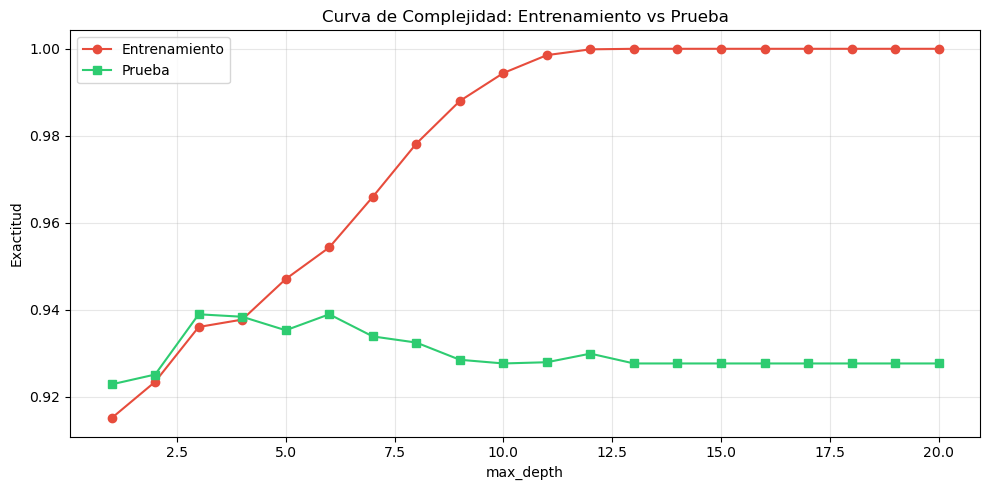

In [25]:
print('=== Efecto de max_depth en el rendimiento ===')
depths = range(1, 21)
train_scores = []
test_scores = []

for d in depths:
    modelo = DecisionTreeClassifier(max_depth=d, random_state=42)
    modelo.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, modelo.predict(X_train)))
    test_scores.append(accuracy_score(y_test, modelo.predict(X_test)))

plt.figure(figsize=(10, 5))
plt.plot(depths, train_scores, 'o-', label='Entrenamiento', color='#e74c3c')
plt.plot(depths, test_scores, 's-', label='Prueba', color='#2ecc71')
plt.xlabel('max_depth')
plt.ylabel('Exactitud')
plt.title('Curva de Complejidad: Entrenamiento vs Prueba')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

=== Arbol con max_depth=10 ===


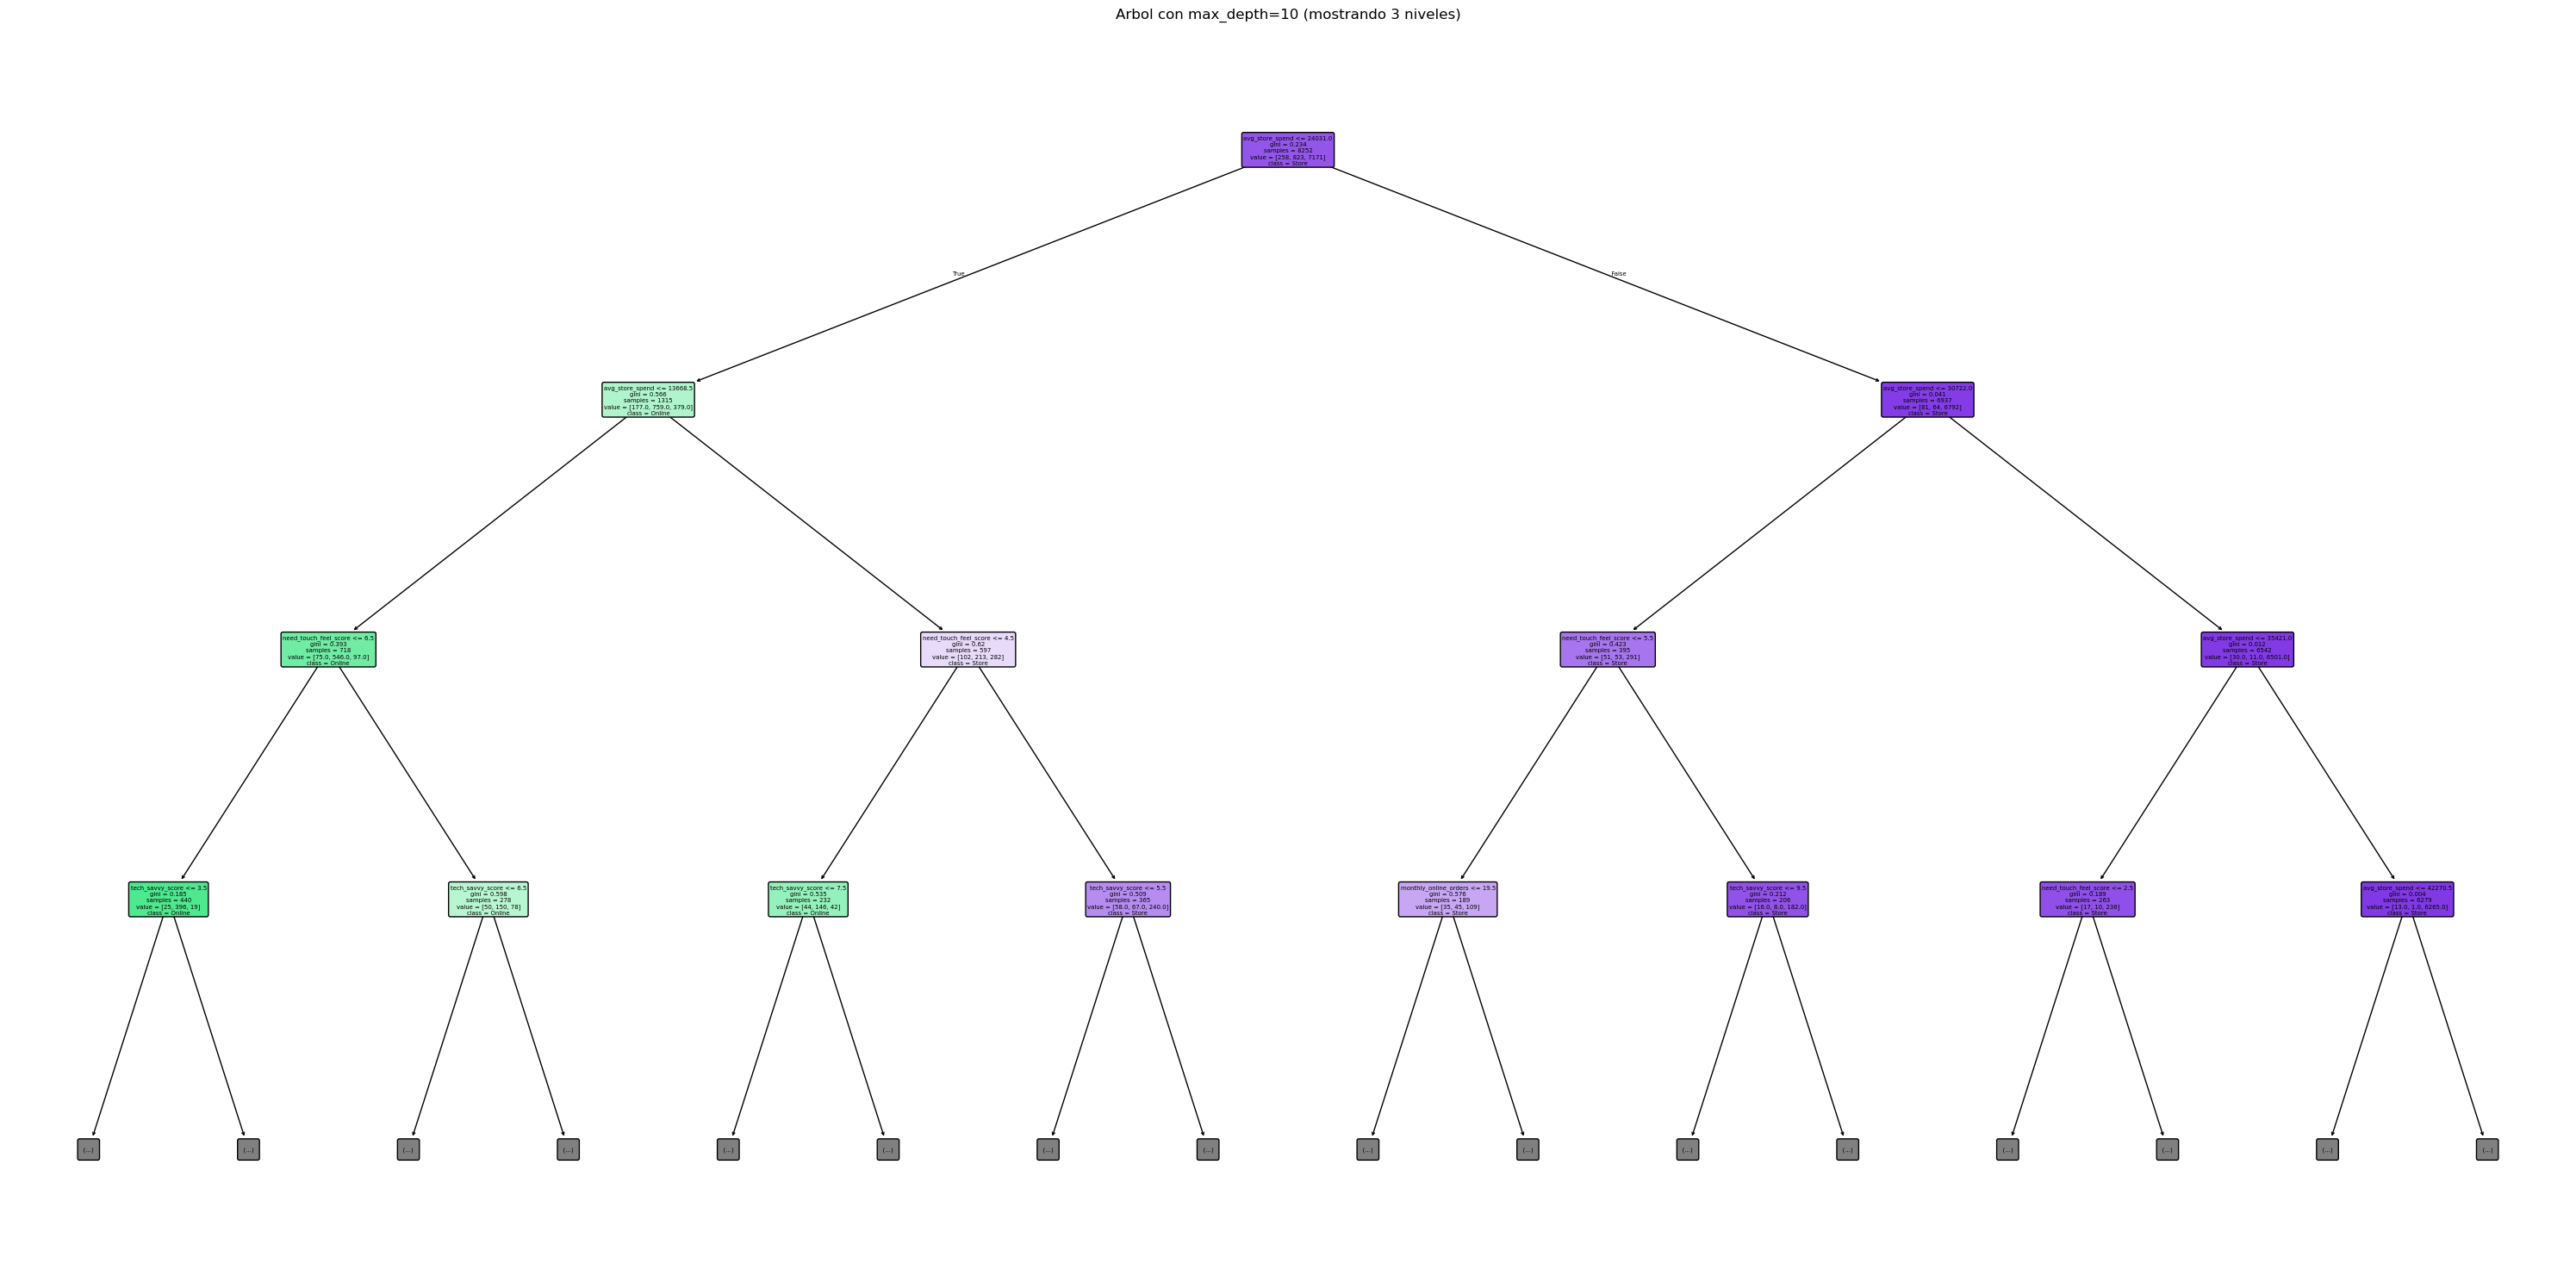

Hojas: 278, Profundidad real: 10


In [26]:
print('=== Arbol con max_depth=10 ===')
arbol_10 = DecisionTreeClassifier(max_depth=10, random_state=42)
arbol_10.fit(X_train, y_train)
plt.figure(figsize=(30, 15))
plot_tree(arbol_10, feature_names=features, class_names=le_target.classes_,
          filled=True, rounded=True, fontsize=5, max_depth=3)
plt.title('Arbol con max_depth=10 (mostrando 3 niveles)')
plt.tight_layout()
plt.show()
print(f'Hojas: {arbol_10.get_n_leaves()}, Profundidad real: {arbol_10.get_depth()}')

=== Arbol con max_depth=3 ===


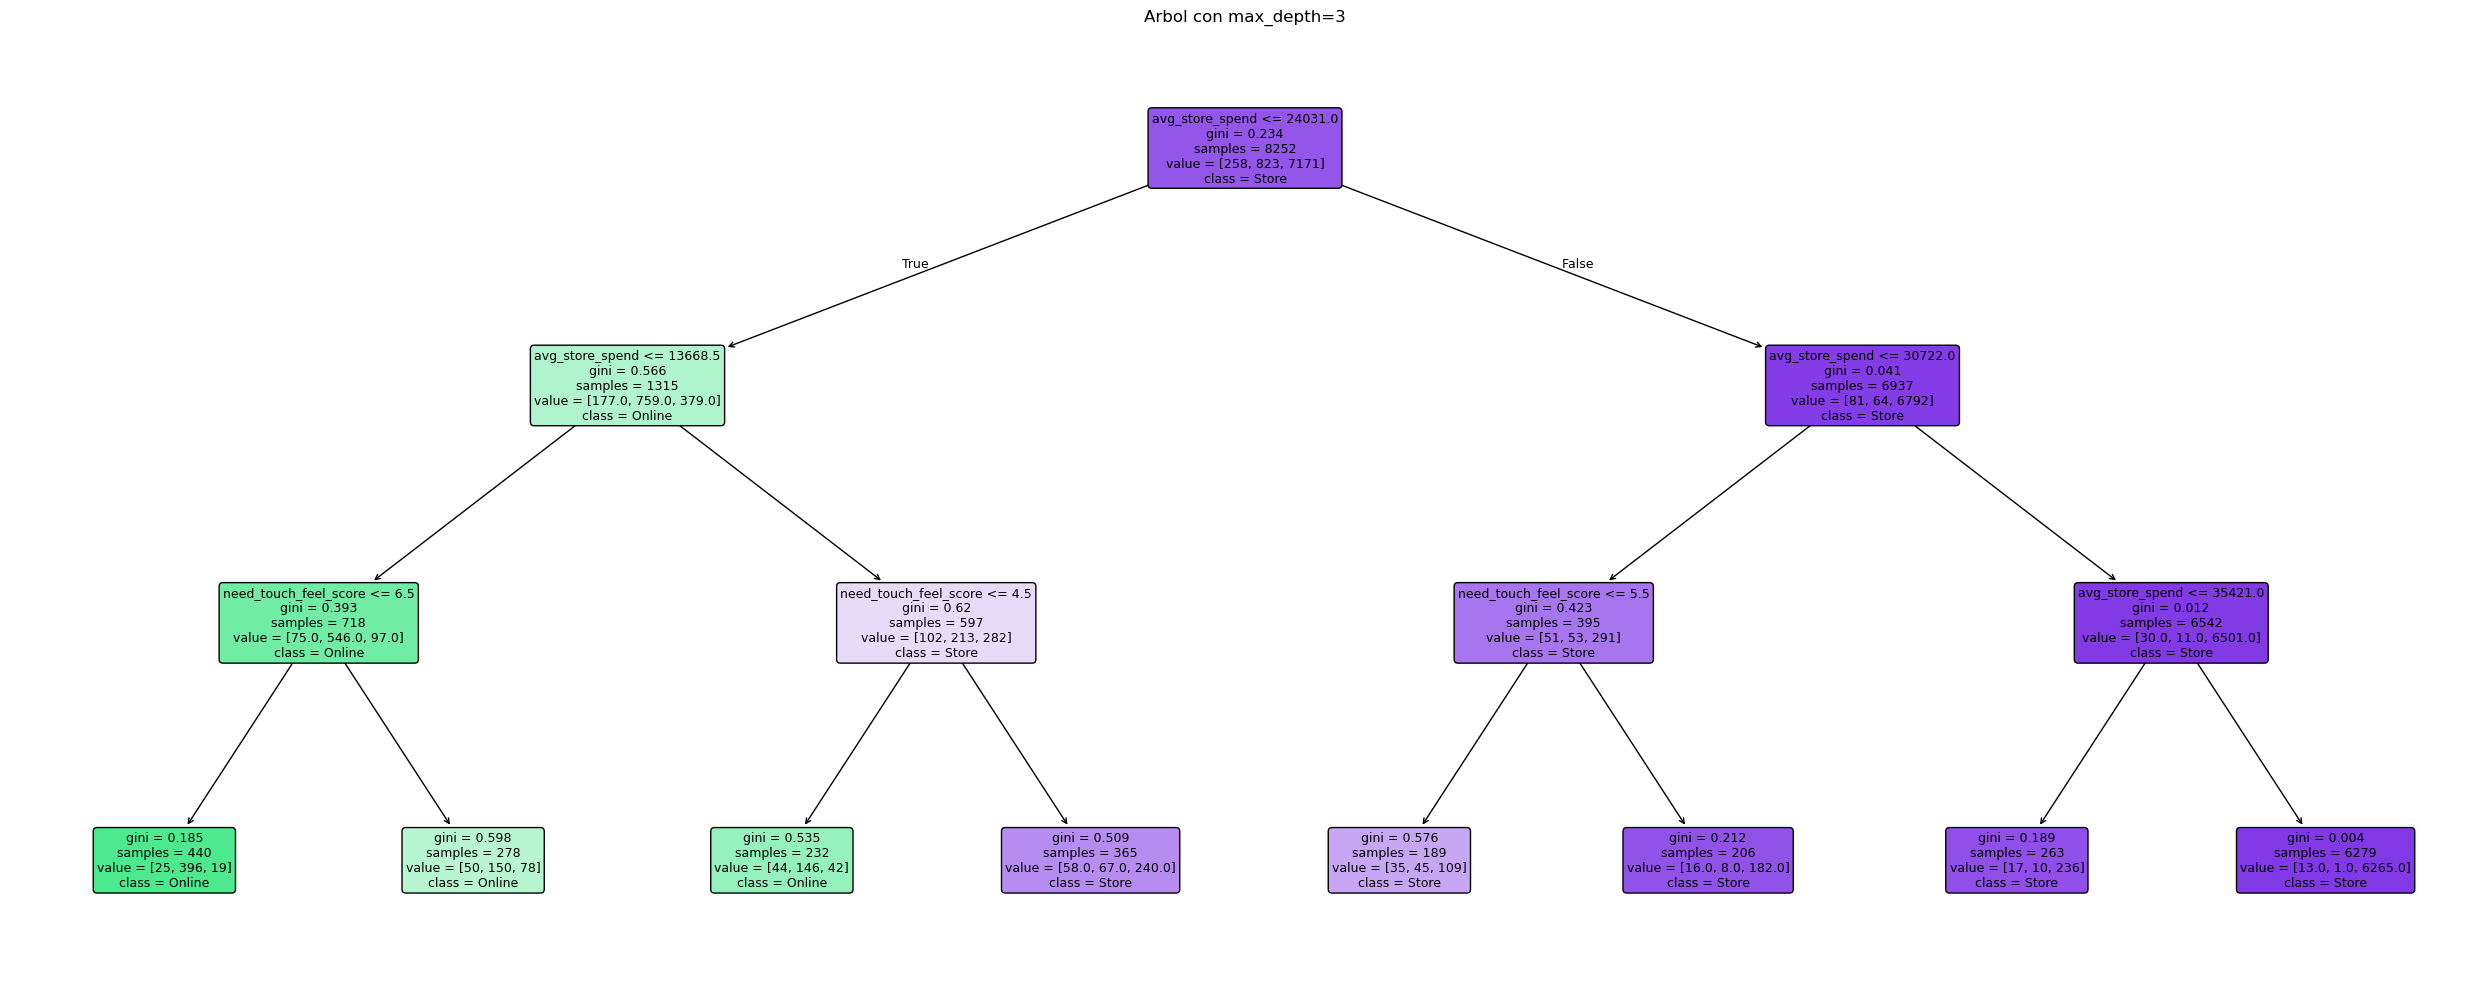

Hojas: 8, Profundidad real: 3
Exactitud Test: 0.9389


In [27]:
print('=== Arbol con max_depth=3 ===')
arbol_3 = DecisionTreeClassifier(max_depth=3, random_state=42)
arbol_3.fit(X_train, y_train)
plt.figure(figsize=(25, 10))
plot_tree(arbol_3, feature_names=features, class_names=le_target.classes_,
          filled=True, rounded=True, fontsize=9)
plt.title('Arbol con max_depth=3')
plt.tight_layout()
plt.show()
print(f'Hojas: {arbol_3.get_n_leaves()}, Profundidad real: {arbol_3.get_depth()}')
print(f'Exactitud Test: {accuracy_score(y_test, arbol_3.predict(X_test)):.4f}')